# 04 — Driver Hints Explorer

**What drives anomalies?** This notebook explores the `top_features` and `top_feature_values`
columns added by `driver_hints.py` (Day 9). For each of the 660 flagged anomalies,
we ranked all 11 engineered features by |z-score| and kept the top 3.

**Key questions:**
1. Which features appear most often as drivers?
2. Are certain parameters always driven by the same feature type?
3. Do driver patterns vary by station?
4. What do the z-score magnitudes look like?
5. Can an operator glance at a row and understand what happened?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 80)

# Load anomalies with driver hints
df = pd.read_csv("../../outputs/anomalies.csv")
anom = df[df["is_anomaly"] == 1].copy()
print(f"Total readings: {len(df):,}")
print(f"Anomalies: {len(anom):,}")
print(f"Columns: {df.columns.tolist()}")

Total readings: 13,194
Anomalies: 660
Columns: ['station_id', 'timestamp', 'parameter', 'value', 'unit', 'anomaly_score', 'is_anomaly', 'top_features', 'top_feature_values']


## 1. Explode Driver Features

Each anomaly has 3 comma-separated driver features. Let's split them into individual rows
so we can count and analyze them.

In [2]:
# Parse the comma-separated driver columns into lists
anom["driver_list"] = anom["top_features"].str.split(", ")
anom["zscore_list"] = anom["top_feature_values"].str.split(", ").apply(
    lambda x: [float(v) for v in x]
)

# Explode into one row per driver
exploded = anom.explode(["driver_list", "zscore_list"])
exploded = exploded.rename(columns={"driver_list": "driver_feature", "zscore_list": "driver_zscore"})
exploded["abs_zscore"] = exploded["driver_zscore"].abs()

# Add rank (1 = strongest driver)
exploded["driver_rank"] = exploded.groupby(exploded.index).cumcount() + 1

print(f"Exploded rows: {len(exploded):,} (660 anomalies × 3 drivers each)")
exploded[["station_id", "parameter", "driver_feature", "driver_zscore", "driver_rank"]].head(9)

Exploded rows: 1,980 (660 anomalies × 3 drivers each)


,station_id,parameter,driver_feature,driver_zscore,driver_rank
121,16018400902,"CONDUCTIVITY, AMBIENT",rolling_mean_30,3.01,1
121,16018400902,"CONDUCTIVITY, AMBIENT",rolling_mean_14,3.01,2
121,16018400902,"CONDUCTIVITY, AMBIENT",rolling_mean_7,3.01,3
128,16018400902,"PHOSPHORUS,UNFILTERED TOTAL",delta,4.61,1
128,16018400902,"PHOSPHORUS,UNFILTERED TOTAL",rolling_std_30,3.16,2
128,16018400902,"PHOSPHORUS,UNFILTERED TOTAL",rolling_std_14,3.1,3
129,16018400902,"RESIDUE,FILTERED",zscore,-2.82,1
129,16018400902,"RESIDUE,FILTERED",delta,-1.81,2
129,16018400902,"RESIDUE,FILTERED",rolling_mean_30,1.76,3


## 2. Feature Frequency — What Drives Anomalies Most?

Which engineered features show up most often in the top-3 drivers?

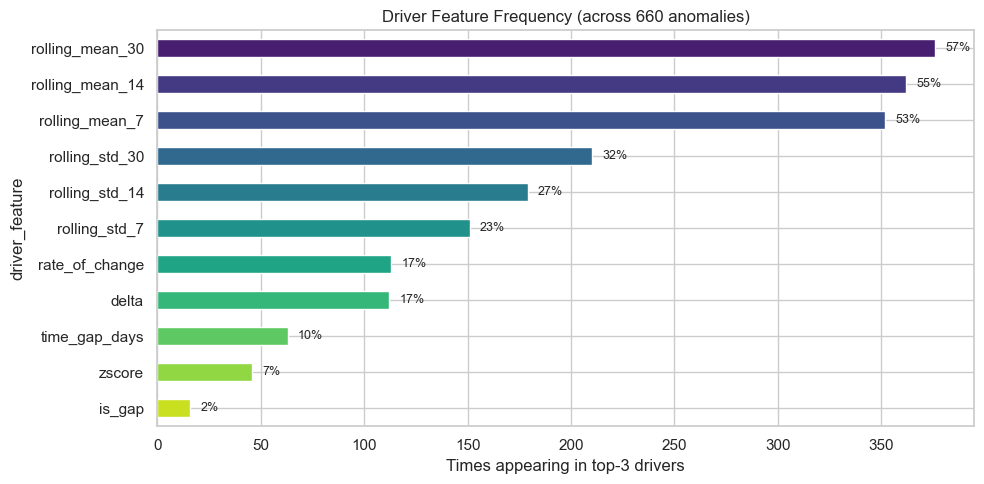

In [3]:
feat_counts = exploded["driver_feature"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
feat_counts.plot.barh(ax=ax, color=sns.color_palette("viridis", len(feat_counts)))
ax.set_xlabel("Times appearing in top-3 drivers")
ax.set_title("Driver Feature Frequency (across 660 anomalies)")
ax.invert_yaxis()

# Add percentage labels
for i, (count, name) in enumerate(zip(feat_counts.values, feat_counts.index)):
    pct = count / len(anom) * 100
    ax.text(count + 5, i, f"{pct:.0f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Feature Frequency by Rank

Does a feature tend to be the **#1** driver or just supporting? This shows whether
rolling means dominate as primary or secondary drivers.

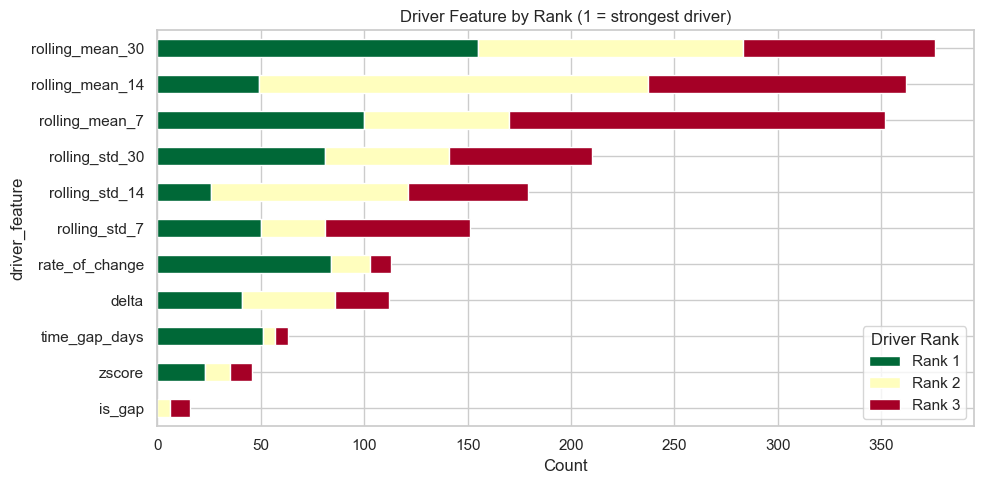

In [4]:
rank_pivot = exploded.groupby(["driver_feature", "driver_rank"]).size().unstack(fill_value=0)
rank_pivot.columns = [f"Rank {c}" for c in rank_pivot.columns]

# Sort by total
rank_pivot["Total"] = rank_pivot.sum(axis=1)
rank_pivot = rank_pivot.sort_values("Total", ascending=False).drop(columns="Total")

fig, ax = plt.subplots(figsize=(10, 5))
rank_pivot.plot.barh(stacked=True, ax=ax, colormap="RdYlGn_r")
ax.set_xlabel("Count")
ax.set_title("Driver Feature by Rank (1 = strongest driver)")
ax.invert_yaxis()
ax.legend(title="Driver Rank", loc="lower right")
plt.tight_layout()
plt.show()

## 4. Z-Score Distribution by Feature

How extreme are the z-scores when each feature is a driver? Higher |z-score| = stronger signal.

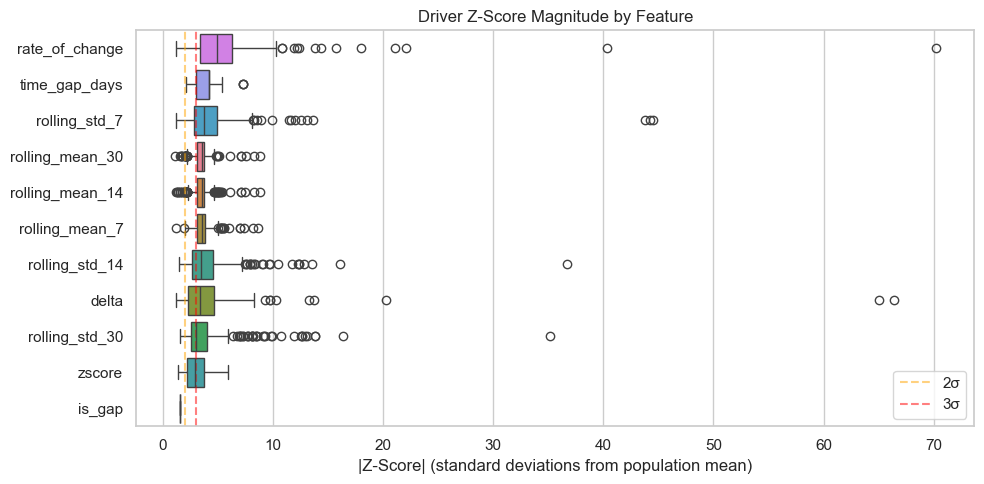

In [5]:
# Order features by median |z-score|
order = exploded.groupby("driver_feature")["abs_zscore"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=exploded, y="driver_feature", x="abs_zscore",
    order=order, hue="driver_feature", legend=False, ax=ax
)
ax.set_xlabel("|Z-Score| (standard deviations from population mean)")
ax.set_ylabel("")
ax.set_title("Driver Z-Score Magnitude by Feature")
ax.axvline(x=2, color="orange", linestyle="--", alpha=0.5, label="2σ")
ax.axvline(x=3, color="red", linestyle="--", alpha=0.5, label="3σ")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Driver Patterns by Station

Do different monitoring stations have different driver profiles? A station dominated by
`delta` vs `rolling_mean` tells a different story (spike events vs level shifts).

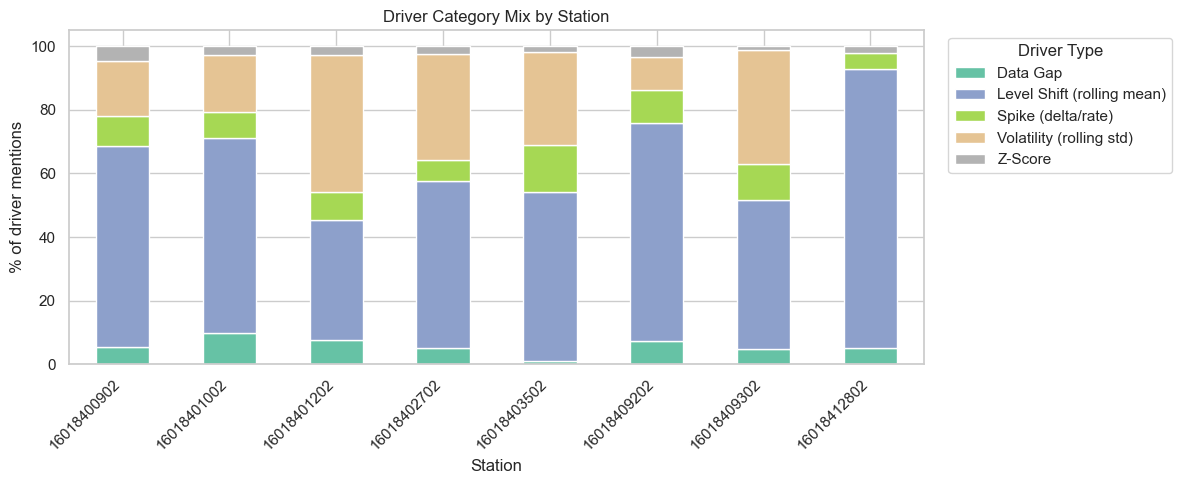

In [6]:
# Group features into categories for cleaner visualization
def categorize_feature(feat):
    if "rolling_mean" in feat:
        return "Level Shift (rolling mean)"
    elif "rolling_std" in feat:
        return "Volatility (rolling std)"
    elif feat in ("delta", "rate_of_change"):
        return "Spike (delta/rate)"
    elif feat == "zscore":
        return "Z-Score"
    elif feat in ("time_gap_days", "is_gap"):
        return "Data Gap"
    return feat

exploded["driver_category"] = exploded["driver_feature"].apply(categorize_feature)

station_cat = exploded.groupby(["station_id", "driver_category"]).size().unstack(fill_value=0)
station_cat_pct = station_cat.div(station_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
station_cat_pct.plot.bar(stacked=True, ax=ax, colormap="Set2")
ax.set_ylabel("% of driver mentions")
ax.set_xlabel("Station")
ax.set_title("Driver Category Mix by Station")
ax.legend(title="Driver Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Driver Patterns by Water Quality Parameter

Which parameters are driven by level shifts vs spikes vs volatility?

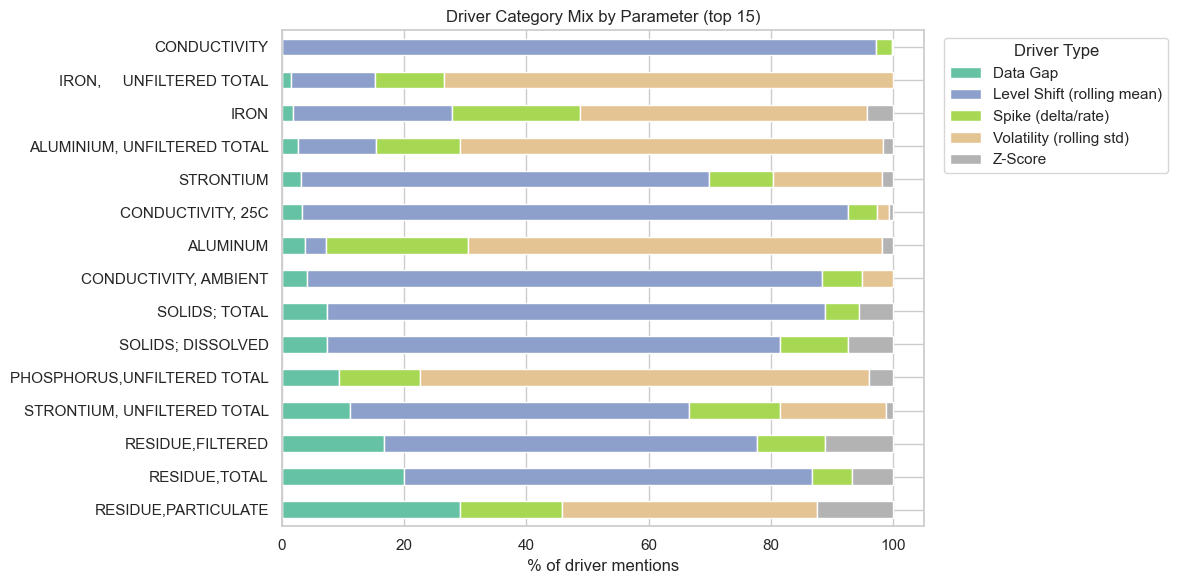

In [7]:
# Top 15 parameters by anomaly count
top_params = anom["parameter"].value_counts().head(15).index

param_cat = (
    exploded[exploded["parameter"].isin(top_params)]
    .groupby(["parameter", "driver_category"]).size()
    .unstack(fill_value=0)
)
param_cat_pct = param_cat.div(param_cat.sum(axis=1), axis=0) * 100
param_cat_pct = param_cat_pct.sort_values(
    param_cat_pct.columns[0], ascending=False
)

fig, ax = plt.subplots(figsize=(12, 6))
param_cat_pct.plot.barh(stacked=True, ax=ax, colormap="Set2")
ax.set_xlabel("% of driver mentions")
ax.set_ylabel("")
ax.set_title("Driver Category Mix by Parameter (top 15)")
ax.legend(title="Driver Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Top Driver Combos

Which 3-feature combinations appear most often? Repeated combos suggest a common pattern
an operator could learn to recognize.

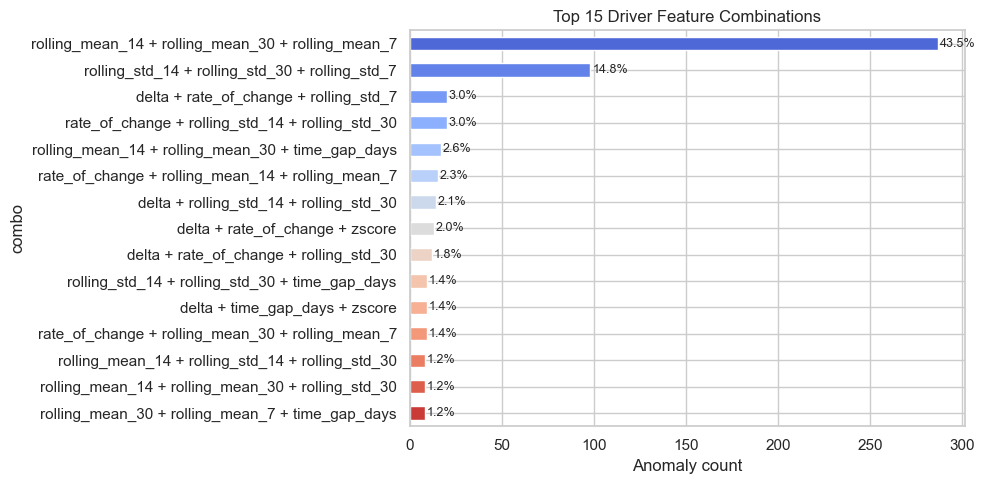

In [8]:
# Normalize combo (sort features alphabetically so order doesn't matter)
anom["combo"] = anom["driver_list"].apply(lambda x: " + ".join(sorted(x)))

combo_counts = anom["combo"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
combo_counts.plot.barh(ax=ax, color=sns.color_palette("coolwarm", len(combo_counts)))
ax.set_xlabel("Anomaly count")
ax.set_title("Top 15 Driver Feature Combinations")
ax.invert_yaxis()

for i, count in enumerate(combo_counts.values):
    pct = count / len(anom) * 100
    ax.text(count + 1, i, f"{pct:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Z-Score Heatmap — Primary Driver per Station × Parameter

For the top parameters and all stations, what's the **average z-score of the #1 driver**?
This shows which station+parameter combos have the strongest anomaly signals.

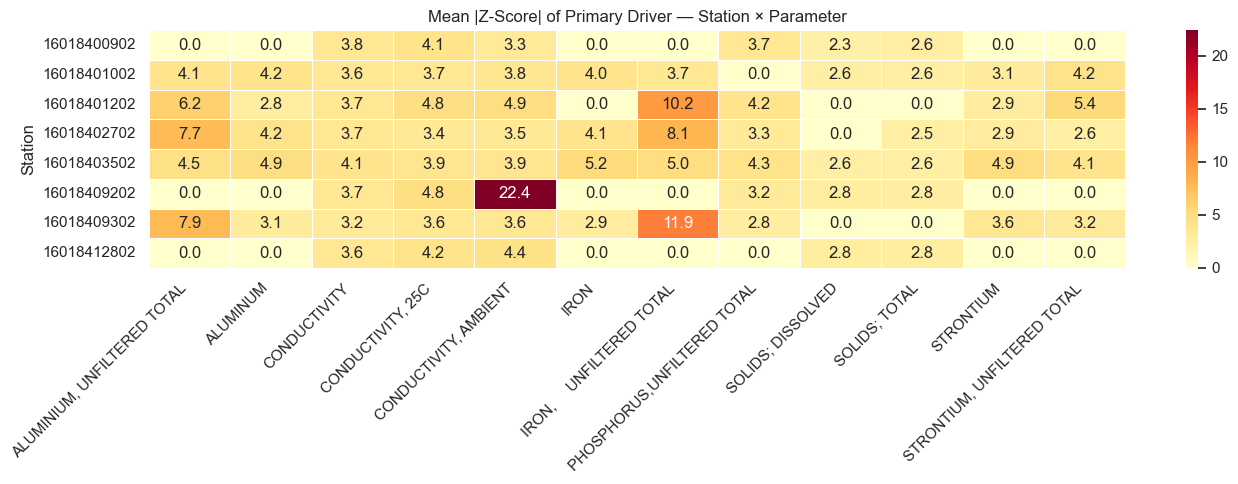

In [10]:
# Filter to rank 1 drivers only
rank1 = exploded[exploded["driver_rank"] == 1].copy()

# Pivot: station × parameter → mean |z-score| of primary driver
top_params_8 = rank1["parameter"].value_counts().head(12).index
heatmap_data = (
    rank1[rank1["parameter"].isin(top_params_8)]
    .groupby(["station_id", "parameter"])["abs_zscore"]
    .mean()
    .unstack(fill_value=0)
    .astype(float)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax
)
ax.set_title("Mean |Z-Score| of Primary Driver — Station × Parameter")
ax.set_ylabel("Station")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Operator View — Sample Anomaly Cards

What an operator would see: a handful of anomalies with plain-English explanations.

In [11]:
# Human-readable feature descriptions
FEATURE_LABELS = {
    "rolling_mean_7": "7-reading avg is unusual",
    "rolling_mean_14": "14-reading avg is unusual",
    "rolling_mean_30": "30-reading avg is unusual",
    "rolling_std_7": "7-reading volatility is unusual",
    "rolling_std_14": "14-reading volatility is unusual",
    "rolling_std_30": "30-reading volatility is unusual",
    "delta": "big jump from previous reading",
    "rate_of_change": "fast rate of change",
    "zscore": "value far from recent average",
    "time_gap_days": "long gap since last reading",
    "is_gap": "data gap detected",
}

# Show top 8 highest-scored anomalies
top8 = anom.nlargest(8, "anomaly_score")

for _, row in top8.iterrows():
    drivers = row["top_features"].split(", ")
    zscores = row["top_feature_values"].split(", ")
    
    print(f"{'='*70}")
    print(f"⚠️  ANOMALY — Score: {row['anomaly_score']:.4f}")
    print(f"   Station:   {row['station_id']}")
    print(f"   Date:      {row['timestamp']}")
    print(f"   Parameter: {row['parameter']}")
    print(f"   Value:     {row['value']} {row['unit']}")
    print(f"   Why:")
    for feat, zs in zip(drivers, zscores):
        label = FEATURE_LABELS.get(feat, feat)
        direction = "above" if float(zs) > 0 else "below"
        print(f"     • {label} ({abs(float(zs)):.1f}σ {direction} normal)")
    print()

⚠️  ANOMALY — Score: 1.0000
   Station:   16018409202
   Date:      2021-01-27T10:10:00
   Parameter: CONDUCTIVITY, AMBIENT
   Value:     10900.0 MICROMHOS/CM (CONDUCTIVITY)
   Why:
     • big jump from previous reading (66.3σ above normal)
     • 7-reading volatility is unusual (44.5σ above normal)
     • fast rate of change (40.4σ above normal)

⚠️  ANOMALY — Score: 0.9641
   Station:   16018409202
   Date:      2021-02-23T10:40:00
   Parameter: CONDUCTIVITY, AMBIENT
   Value:     1208.0 MICROMHOS/CM (CONDUCTIVITY)
   Why:
     • fast rate of change (70.2σ below normal)
     • big jump from previous reading (65.0σ below normal)
     • 7-reading volatility is unusual (44.2σ above normal)

⚠️  ANOMALY — Score: 0.9588
   Station:   16018409302
   Date:      2019-09-11T09:50:00
   Parameter: IRON,     UNFILTERED TOTAL
   Value:     3580.0 µg/L
   Why:
     • fast rate of change (14.3σ above normal)
     • big jump from previous reading (13.8σ above normal)
     • 30-reading volatility is

## 10. Positive vs Negative Z-Scores

Are drivers mostly **above normal** (positive z-score = high readings) or **below normal**
(negative z-score = unusual drops)? This affects how an operator interprets the alert.

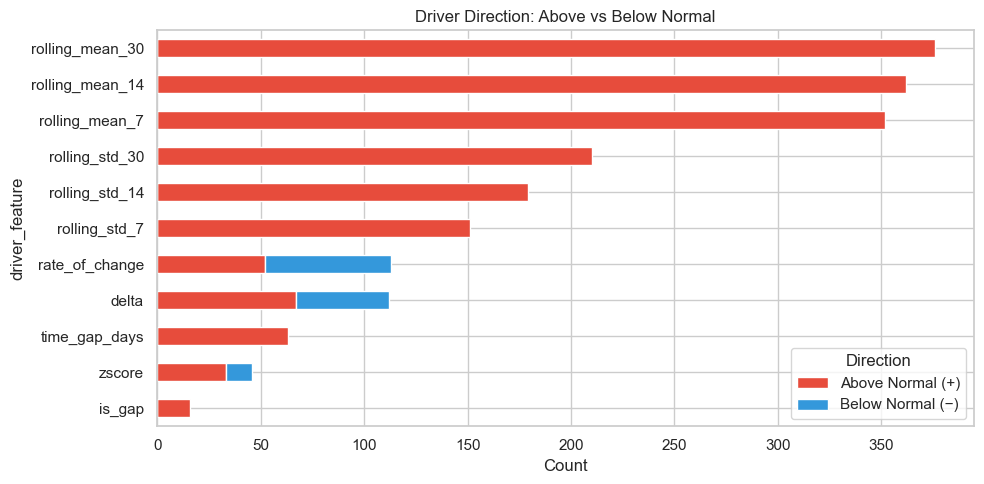

In [12]:
exploded["direction"] = np.where(exploded["driver_zscore"] > 0, "Above Normal (+)", "Below Normal (−)")

dir_by_feat = exploded.groupby(["driver_feature", "direction"]).size().unstack(fill_value=0)
dir_by_feat["total"] = dir_by_feat.sum(axis=1)
dir_by_feat = dir_by_feat.sort_values("total", ascending=False).drop(columns="total")

fig, ax = plt.subplots(figsize=(10, 5))
dir_by_feat.plot.barh(stacked=True, ax=ax, color=["#e74c3c", "#3498db"])
ax.set_xlabel("Count")
ax.set_title("Driver Direction: Above vs Below Normal")
ax.invert_yaxis()
ax.legend(title="Direction")
plt.tight_layout()
plt.show()

## 11. Timeline — Driver Types Over Time

Are spike-driven anomalies clustered in time? Do level shifts appear seasonally?

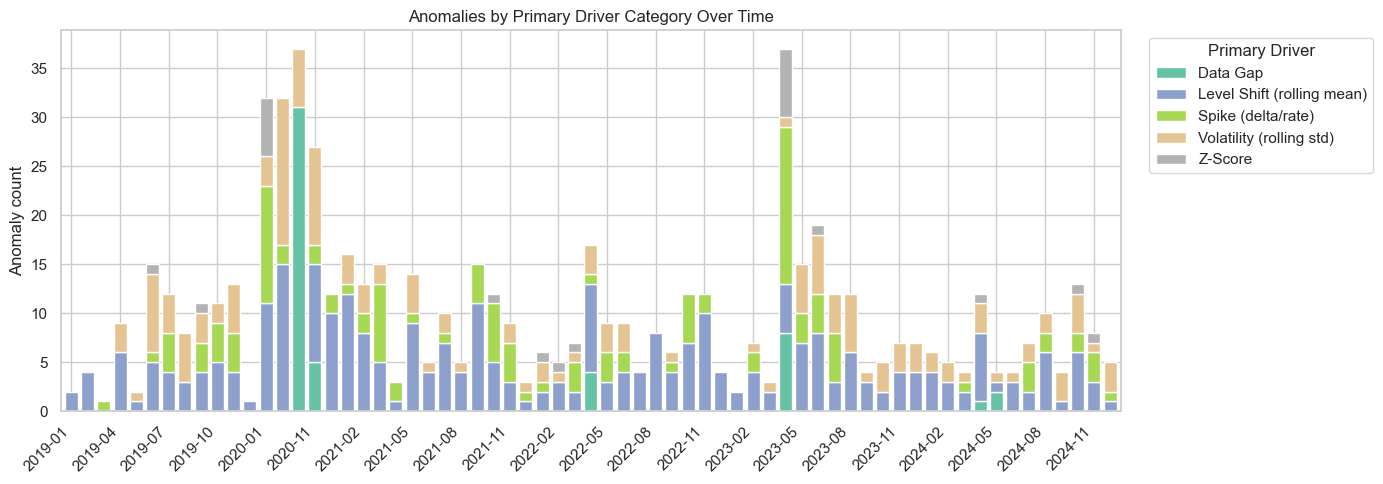

In [13]:
anom["timestamp_dt"] = pd.to_datetime(anom["timestamp"])
anom["month"] = anom["timestamp_dt"].dt.to_period("M")

# Primary driver category for each anomaly
anom["primary_driver"] = anom["driver_list"].str[0]
anom["primary_category"] = anom["primary_driver"].apply(categorize_feature)

timeline = anom.groupby(["month", "primary_category"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
timeline.plot.bar(stacked=True, ax=ax, colormap="Set2", width=0.8)
ax.set_ylabel("Anomaly count")
ax.set_xlabel("")
ax.set_title("Anomalies by Primary Driver Category Over Time")
ax.legend(title="Primary Driver", bbox_to_anchor=(1.02, 1), loc="upper left")

# Thin out x-axis labels
ticks = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(ticks[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 12. Summary Statistics

In [14]:
print("=== Driver Hints Summary ===")
print(f"Total anomalies with hints: {len(anom)}")
print(f"Unique driver features used: {exploded['driver_feature'].nunique()}")
print(f"Unique driver combos: {anom['combo'].nunique()}")
print()

# Primary driver distribution
print("Primary driver (rank 1) breakdown:")
primary = exploded[exploded["driver_rank"] == 1]["driver_category"].value_counts()
for cat, count in primary.items():
    pct = count / len(anom) * 100
    print(f"  {cat}: {count} ({pct:.0f}%)")

print()
print("Mean |z-score| by rank:")
for rank in [1, 2, 3]:
    mean_z = exploded[exploded["driver_rank"] == rank]["abs_zscore"].mean()
    print(f"  Rank {rank}: {mean_z:.2f}σ")

print()
print("Interpretation:")
print("  • Rolling means dominating → anomalies are mostly sustained level shifts")
print("  • Delta/rate appearing → some anomalies are sudden spikes")
print("  • Operators should look for: 'has this parameter been running high/low for multiple readings?'")

=== Driver Hints Summary ===
Total anomalies with hints: 660
Unique driver features used: 11
Unique driver combos: 63

Primary driver (rank 1) breakdown:
  Level Shift (rolling mean): 304 (46%)
  Volatility (rolling std): 157 (24%)
  Spike (delta/rate): 125 (19%)
  Data Gap: 51 (8%)
  Z-Score: 23 (3%)

Mean |z-score| by rank:
  Rank 1: 4.61σ
  Rank 2: 3.93σ
  Rank 3: 3.57σ

Interpretation:
  • Rolling means dominating → anomalies are mostly sustained level shifts
  • Delta/rate appearing → some anomalies are sudden spikes
  • Operators should look for: 'has this parameter been running high/low for multiple readings?'
